# **Project 49: OpenCV Project**

***OpenCV*** : *(Open Source Computer Vision Library) is an open-source computer vision and machine learning software library. It provides a comprehensive set of tools and functions for image processing, real-time computer vision, and machine learning applications. OpenCV is widely used in various fields, including robotics, artificial intelligence, and augmented reality.*

***OS*** : *The os module in Python provides a way to interact with the operating system, allowing users to perform tasks like file manipulation, directory management, and executing system commands. It helps in accessing environment variables and navigating the file system efficiently.*

***Matplotlib*** : *Matplotlib is a versatile plotting library in Python that allows users to create high-quality visualizations, including static, interactive, and animated plots. It is widely used for data visualization, making complex datasets more interpretable and accessible.*

***imutils*** : *A collection of convenience functions for computer vision tasks that simplify common image processing operations. It provides easy-to-use utilities for image resizing, rotating, and displaying, among others.*

***NumPy*** : *A fundamental package for numerical computing in Python, providing support for large, multi-dimensional arrays and matrices. It offers a wide range of mathematical functions to operate on these arrays efficiently.*

**Importing these libraries for Edge Detection, Face and Eye Detection, Video Processing, and Thresholding.**

In [1]:
import cv2
import os
import numpy as np
import imutils
import matplotlib.pyplot as plt

# **Edge Detection**

***Canny Edge Detection*** : *is an edge detection algorithm that identifies the boundaries of objects within an image by detecting rapid changes in intensity. It involves a multi-stage process that includes smoothing the image, finding gradients, applying non-maximum suppression, and using hysteresis thresholding to finalize edge detection. This technique is widely used in computer vision applications for its effectiveness in detecting edges with good accuracy and low noise sensitivity.*

- **Initialization: The CannyEdgeDetection class is initialized with the image file path.**

- **Edge Detection: The canny_edge method reads the image in grayscale and applies Canny edge detection with specified threshold values.**

- **Saving Output: The resulting edge-detected image is saved as "test.jpg".**

- **Visualization: The method creates a side-by-side comparison of the original and edge-detected images using Matplotlib.**

- **Display: The images are displayed with titles, allowing for easy visual comparison.**

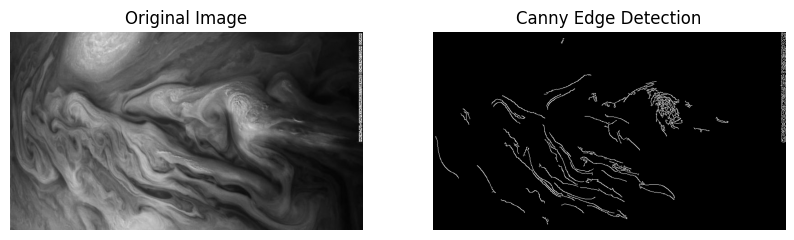

In [2]:
class CannyEdgeDetection:

    def __init__(self, path):
        self.image_path = path

    def canny_edge(self):

        img = cv2.imread(self.image_path, 0)
        edges = cv2.Canny(img, 50, 200)

        cv2.imwrite(os.path.join("test.jpg"), edges)

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(img, cmap='gray')
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(edges, cmap='gray')
        plt.title("Canny Edge Detection")
        plt.axis('off')

        plt.show()


detector = CannyEdgeDetection("test.jpg")
detector.canny_edge()

# **Thresholding**

***Thresholding*** : *is a fundamental image processing technique used to convert a grayscale image into a binary image by setting a specific threshold value. Pixels with intensity values above the threshold are converted to one value (usually white), while those below are converted to another (usually black). This method is particularly useful for segmenting objects from the background and is commonly employed in applications such as object detection, document scanning, and image analysis. Variants like adaptive thresholding and Otsu's method help to address challenges posed by varying lighting conditions and bimodal histograms, respectively.*

- **Class Initialization: The Thresholding class is initialized with the image file path. The image is loaded in grayscale during initialization.**

- **Simple Thresholding: The simple_thres method applies basic thresholding, setting pixel values below 127 to 0 and those above to 255, and saves the result.**

- **Adaptive Thresholding: The adaptive_thres method uses median blurring to reduce noise and then applies adaptive thresholding to handle varying lighting conditions, saving the output.**

- **Otsu's Binarization: The otsu_binarization method applies Gaussian blur followed by Otsu's method to find an optimal threshold for bimodal images, saving the resulting image.**

- **Displaying Results: The display_results method visualizes the original and thresholded images (simple, adaptive, and Otsu's) using Matplotlib for comparison.**

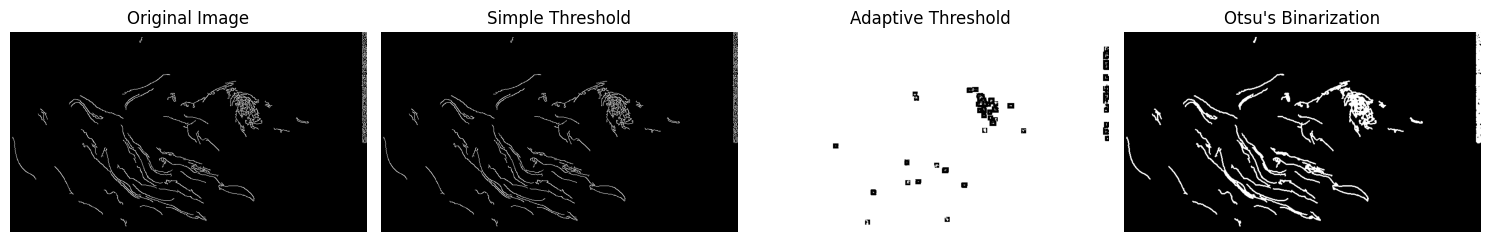

In [3]:
class Thresholding:

    def __init__(self, path):
        self.image_path = path
        self.image = cv2.imread(self.image_path, 0)

    def simple_thres(self):
        ret, thresh1 = cv2.threshold(self.image, 127, 255, cv2.THRESH_BINARY)
        cv2.imwrite(os.path.join("test.jpg"), thresh1)
        return thresh1

    def adaptive_thres(self):
        img = cv2.medianBlur(self.image, 5)
        th2 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
        cv2.imwrite(os.path.join("test.jpg"), th2)
        return th2

    def otsu_binarization(self):
        blur = cv2.GaussianBlur(self.image, (5, 5), 0)
        ret3, th3 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        cv2.imwrite(os.path.join("test.jpg"), th3)
        return th3

    def display_results(self, simple, adaptive, otsu):
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 4, 1)
        plt.imshow(self.image, cmap='gray')
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 4, 2)
        plt.imshow(simple, cmap='gray')
        plt.title("Simple Threshold")
        plt.axis('off')

        plt.subplot(1, 4, 3)
        plt.imshow(adaptive, cmap='gray')
        plt.title("Adaptive Threshold")
        plt.axis('off')

        plt.subplot(1, 4, 4)
        plt.imshow(otsu, cmap='gray')
        plt.title("Otsu's Binarization")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

detector = Thresholding("test.jpg")
simple = detector.simple_thres()
adaptive = detector.adaptive_thres()
otsu = detector.otsu_binarization()

detector.display_results(simple, adaptive, otsu)

# **Video Processing**

***Video Processing*** : *involves the manipulation and analysis of video data to extract meaningful information or enhance visual quality. Techniques such as frame extraction, object detection, motion tracking, and image stabilization are commonly employed in various applications, including surveillance, sports analytics, and video editing. By applying algorithms and computer vision methods, video processing enables real-time analysis and automation, allowing for tasks such as activity recognition and scene understanding. This field is crucial in areas such as entertainment, security, and robotics, where interpreting visual data is essential.*

 - **Class Initialization: The VideoAnalytics class is initialized with the path to a video file, which is stored in the video_path attribute.**

- **Video Processing: The process method opens the video file using OpenCV's VideoCapture. It allows for reading frames from the video or directly from a camera if 0 is passed.**

- **Directory Creation: A directory named "data" is created to store the extracted frames if it doesn't already exist. This is handled with error checking to ensure the directory is created successfully.**

- **Frame Extraction: Inside a loop, each frame of the video is read and saved as a JPEG file in the "data" directory with a sequential filename format (frame_0000.jpg, frame_0001.jpg, etc.). The loop continues until there are no more frames to read.**

- **Resource Management: After processing, the video capture object is released, and any OpenCV windows are closed, ensuring that system resources are freed.**

In [4]:
class VideoAnalytics:

    def __init__(self, video_path):
        self.video_path = video_path

    def process(self):
        cam = cv2.VideoCapture(self.video_path)


        basepath = os.path.join('data')
        try:
            if not os.path.exists(basepath):
                os.makedirs(basepath)
        except OSError:
            print('Error: Creating Directory of Data')

        currentframe = 0
        while True:
            ret, frame = cam.read()
            if ret:
                name = os.path.join(basepath, f'frame_{currentframe:04d}.jpg')
                print('Creating...' + name)
                cv2.imwrite(name, frame)
                currentframe += 1
            else:
                break

        cam.release()
        cv2.destroyAllWindows()


video_name = "test_video.mp4"
video_analytics = VideoAnalytics(video_name)
video_analytics.process()

Creating...data/frame_0000.jpg
Creating...data/frame_0001.jpg
Creating...data/frame_0002.jpg
Creating...data/frame_0003.jpg
Creating...data/frame_0004.jpg
Creating...data/frame_0005.jpg
Creating...data/frame_0006.jpg
Creating...data/frame_0007.jpg
Creating...data/frame_0008.jpg
Creating...data/frame_0009.jpg
Creating...data/frame_0010.jpg
Creating...data/frame_0011.jpg
Creating...data/frame_0012.jpg
Creating...data/frame_0013.jpg
Creating...data/frame_0014.jpg
Creating...data/frame_0015.jpg
Creating...data/frame_0016.jpg
Creating...data/frame_0017.jpg
Creating...data/frame_0018.jpg
Creating...data/frame_0019.jpg
Creating...data/frame_0020.jpg
Creating...data/frame_0021.jpg
Creating...data/frame_0022.jpg
Creating...data/frame_0023.jpg
Creating...data/frame_0024.jpg
Creating...data/frame_0025.jpg
Creating...data/frame_0026.jpg
Creating...data/frame_0027.jpg
Creating...data/frame_0028.jpg
Creating...data/frame_0029.jpg
Creating...data/frame_0030.jpg
Creating...data/frame_0031.jpg
Creating

# **Face And Eye Dectection**

***Face - Eye Detection In OpenCV*** : *Face and eye detection is a computer vision technique used to identify and locate human faces and their eyes within digital images or video streams. OpenCV utilizes Haar Cascades, a machine learning object detection method, to efficiently classify and detect these features. The process involves converting the image to grayscale, applying histogram equalization for contrast improvement, and then using trained classifiers to detect faces and eyes based on patterns in pixel intensity. This technique is widely employed in applications such as surveillance, human-computer interaction, and image processing for recognizing individuals and enhancing user experiences.*

- **Function Definition: The detectAndDisplay function takes an image along with pre-trained Haar cascades for face and eye detection. It converts the image to grayscale and enhances the histogram for better feature detection.**

- **Face Detection: Using the detectMultiScale method, the function identifies faces in the grayscale image. For each detected face, an ellipse is drawn around it, and a region of interest (ROI) is created for eye detection.**

- **Eye Detection: Within the detected face ROI, the function applies the eye cascade to identify eyes, drawing circles around each detected eye.**

- **Image Display: The image with detected faces and eyes is displayed using Matplotlib, converting the color format from BGR to RGB for correct color representation.**

- **Main Detection Function: The detect function loads the Haar cascade XML files, reads an input image, and calls detectAndDisplay to process the image. It includes error handling for loading the cascades and the image.**

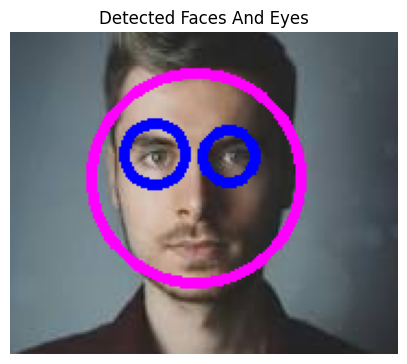

In [5]:
def detectAndDisplay(image, face_cascade, eyes_cascade):

    frame_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    frame_gray = cv2.equalizeHist(frame_gray)

    faces = face_cascade.detectMultiScale(frame_gray, scaleFactor=1.1, minNeighbors=5)
    for (x, y, w, h) in faces:
        center = (x + w // 2, y + h // 2)
        cv2.ellipse(image, center, (w // 2, h // 2), 0, 0, 360, (255, 0, 255), 4)
        faceROI = frame_gray[y:y + h, x:x + w]

        eyes = eyes_cascade.detectMultiScale(faceROI, scaleFactor=1.1, minNeighbors=10)
        for (x2, y2, w2, h2) in eyes:
            eye_center = (x + x2 + w2 // 2, y + y2 + h2 // 2)
            radius = int(round((w2 + h2) * 0.25))
            cv2.circle(image, eye_center, radius, (255, 0, 0), 4)

    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Detected Faces And Eyes')
    plt.show()

def detect(image_path):


    eyes_cascade_name = "haarcascade_eye.xml"
    face_cascade_name = "haarcascade_frontalface_default.xml"

    face_cascade = cv2.CascadeClassifier()
    eyes_cascade = cv2.CascadeClassifier()

    if not face_cascade.load(cv2.samples.findFile(face_cascade_name)):
        print('--(!)Error Loading Face Cascade')
        exit(0)
    if not eyes_cascade.load(cv2.samples.findFile(eyes_cascade_name)):
        print('--(!)Error Loading Eyes Cascade')
        exit(0)

    image = cv2.imread(image_path)
    if image is None:
        print('--(!) Error Loading Image')
        exit(0)

    detectAndDisplay(image, face_cascade, eyes_cascade)

image_path = "Face Eye Detection.jpg"
detect(image_path)

# **Airthemetic Operations**

***Arithmetic Operations*** : *In image processing refer to basic operations performed on images, such as addition and subtraction. These operations can be used to enhance images, combine multiple images, or analyze image data.*

- **Addition: Combines two images by overlaying them, adjusting their brightness or intensity levels. The operation typically involves weighted sums of the pixel values from both images, allowing for varying degrees of transparency.**

- **Subtraction: Computes the difference between two images, which can be useful for background subtraction or highlighting changes between frames in a video sequence. This operation identifies areas where one image differs from another.**

**Code Explanation:**

- **Image Addition: This class allows for the addition of two images using weighted addition, which combines pixel values from both images based on specified weights to create a blended result.**

- **Image Subtraction: It provides a method to subtract one image from another, enabling pixel-wise removal of corresponding pixel values, useful for highlighting differences between images.**

- **Dynamic Resizing: Both images are resized to a fixed dimension (1050x1610) before performing operations, ensuring consistent dimensions for processing.**

- **Visualization: The display_result method visually presents the source and destination images alongside the result of the arithmetic operation, enhancing interpretability and understanding of the effects.**

- **Modular Structure: Each operation is encapsulated in separate methods, promoting code organization and allowing easy expansion or modification of arithmetic functionalities in the future.**

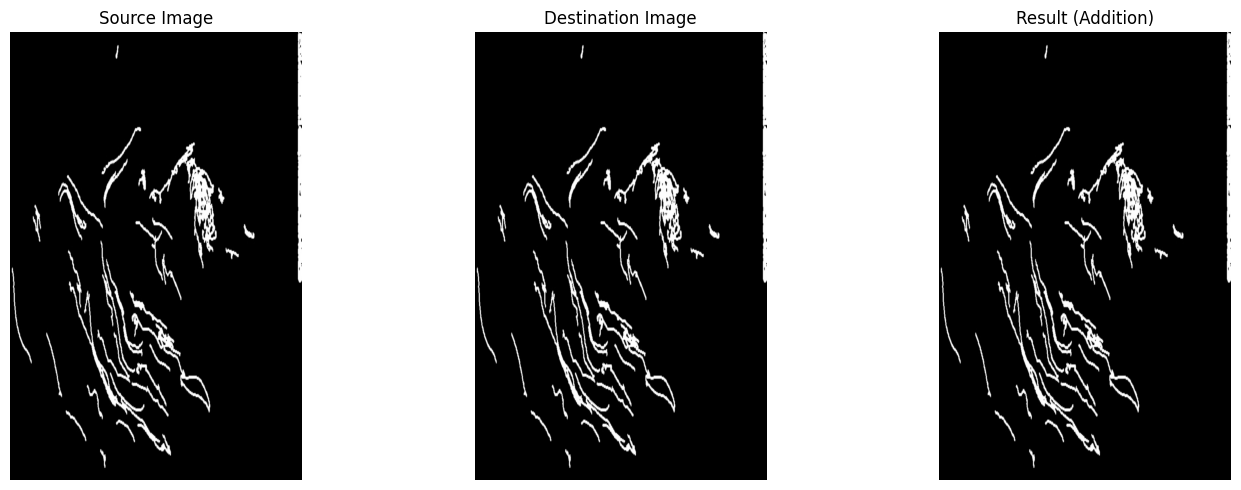

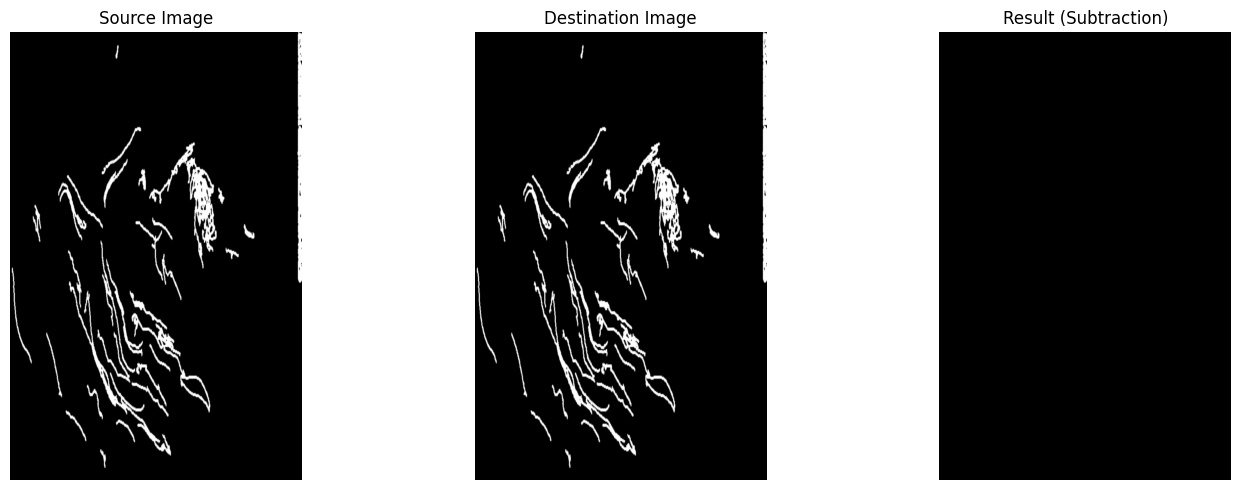

In [6]:
class ArithmeticOperations:

    def __init__(self, path01, path02):
        self.image_path_src = path01
        self.image_path_dest = path02

    def add(self):

        image_src = cv2.imread(self.image_path_src)
        image_dest = cv2.imread(self.image_path_dest)

        image_src = cv2.resize(image_src, (1050, 1610))
        image_dest = cv2.resize(image_dest, (1050, 1610))

        weighted_sum = cv2.addWeighted(image_src, 0.5, image_dest, 0.5, 0)
        cv2.imwrite(os.path.join("test.jpg"), weighted_sum)

        self.display_result("Addition", image_src, image_dest, weighted_sum)

    def subtract(self):

        image_src = cv2.imread(self.image_path_src)
        image_dest = cv2.imread(self.image_path_dest)

        image_src = cv2.resize(image_src, (1050, 1610))
        image_dest = cv2.resize(image_dest, (1050, 1610))

        remaining_image = cv2.subtract(image_src, image_dest)
        cv2.imwrite(os.path.join("test.jpg"), remaining_image)

        self.display_result("Subtraction", image_src, image_dest, remaining_image)

    def display_result(self, operation, image1, image2, result_image):
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
        plt.title(f"Source Image")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
        plt.title(f"Destination Image")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
        plt.title(f"Result ({operation})")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

src_image_path = "test.jpg"
dest_image_path = "test.jpg"

operations = ArithmeticOperations(src_image_path, dest_image_path)
operations.add()
operations.subtract()

# **ColorSpaces**

***Color Spaces*** : *A color space is a specific organization of colors that allows for the representation and manipulation of color in digital images. Different color spaces, such as BGR, RGB, HSV, and Grayscale, provide varying ways to interpret color information, enabling tasks like color detection, image processing, and visual analysis. Understanding these spaces is crucial for effective image manipulation and analysis in computer vision applications.*

- **Color Conversion: The class provides methods to convert images from BGR (Blue, Green, Red) format to other color spaces, specifically HSV (Hue, Saturation, Value) and grayscale.**

- **Blue Color Tracking: It includes a method to track and isolate blue colors within an image by converting it to the HSV color space and applying a color mask.**

- **Image Display: The display_images method allows side-by-side visualization of the original and processed images, enhancing the understanding of the effects of color conversions and tracking.**

- **Modular Design: Each functionality is encapsulated in separate methods, promoting a clean and organized structure that makes it easy to extend or modify.**

- **Visualization Support: The use of Matplotlib for displaying images ensures that the outputs are visually informative, particularly useful for tasks related to color detection and transformation.**

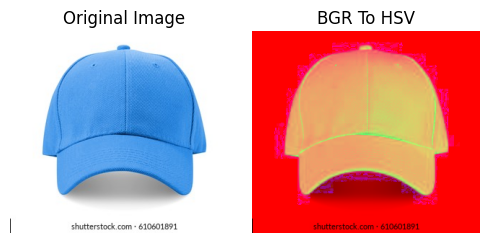

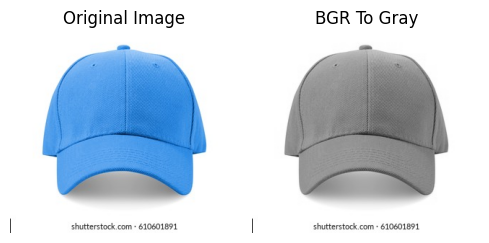

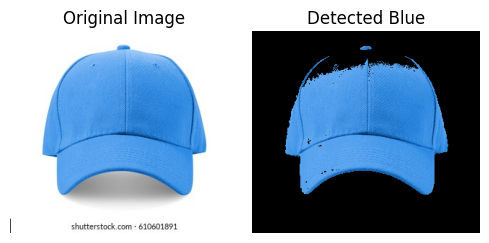

In [7]:
class ColorSpaces:

    def __init__(self, path):
        self.image_path = path
        self.image = cv2.imread(self.image_path)


    def convert_bgr_hsv(self):
        hsv = cv2.cvtColor(self.image, cv2.COLOR_BGR2HSV)
        self.display_images(self.image, hsv, "Original Image", "BGR To HSV")


    def convert_bgr_gray(self):
        gray = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
        self.display_images(self.image, gray, "Original Image", "BGR To Gray")


    def track_blue(self):
        hsv = cv2.cvtColor(self.image, cv2.COLOR_BGR2HSV)
        lower_blue = np.array([100, 150, 0])
        upper_blue = np.array([140, 255, 255])

        mask = cv2.inRange(hsv, lower_blue, upper_blue)
        res = cv2.bitwise_and(self.image, self.image, mask=mask)
        self.display_images(self.image, res, "Original Image", "Detected Blue")


    def display_images(self, original, processed, title1, title2):
        plt.figure(figsize=(5, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        plt.title(title1)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
        plt.title(title2)
        plt.axis('off')

        plt.tight_layout()
        plt.show()


image_path = "blue_cap.jpg"
color_space = ColorSpaces(image_path)
color_space.convert_bgr_hsv()
color_space.convert_bgr_gray()
color_space.track_blue()

# **Morphology**

***Morphology*** : *A technique in image processing that focuses on the shape and structure of objects within an image. It uses operations like erosion, dilation, opening, and closing to manipulate the geometrical structures based on their shapes, allowing for tasks like noise reduction, object separation, and boundary extraction. Morphological operations are typically applied to binary or grayscale images.*

- **Initialization: The class is initialized with the path to a grayscale image, which is read and stored for subsequent morphological operations.**

- **Erosion: The erode method reduces the size of the white regions in the image by applying a structuring element, effectively removing small-scale noise and details from the foreground objects.**

- **Dilation: The dilate method increases the size of the white regions, which enhances the foreground objects and can help fill in small holes within them, making it useful for emphasizing features.**

- **Morphological Operations: The class includes methods for opening (erosion followed by dilation) to remove noise and closing (dilation followed by erosion) to close small holes in the foreground objects, both essential for preprocessing in image analysis.**

- **Custom Structuring Elements: The get_structuring_element method allows the user to obtain different shapes of structuring elements (rectangle, ellipse, or cross) for use in morphological operations, providing flexibility based on the requirements of the specific image processing task.**

---------------------------------------------------------------


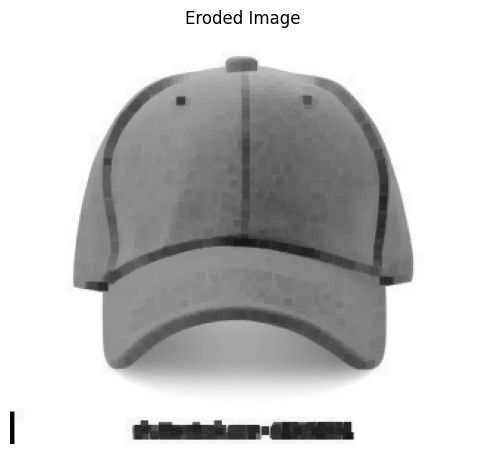

---------------------------------------------------------------


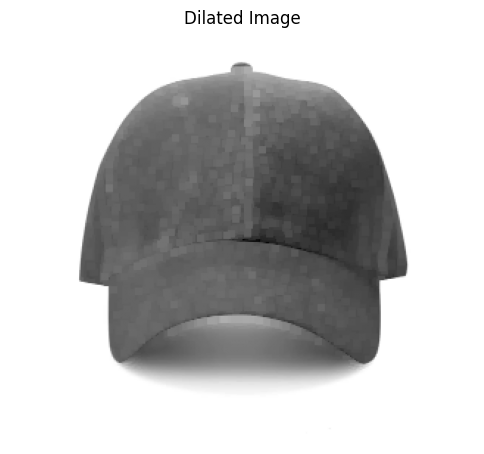

---------------------------------------------------------------


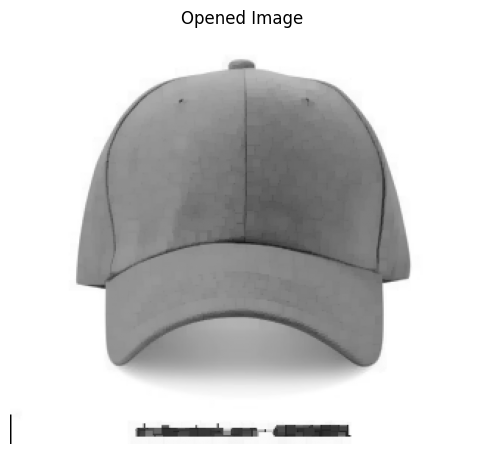

---------------------------------------------------------------


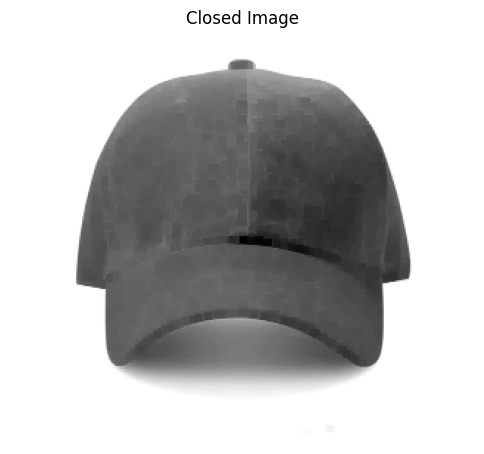

In [8]:
class Morphological:

    def __init__(self, path):
        self.image_path = path
        self.image = cv2.imread(self.image_path, 0)

    def display_image(self, title, image):
        print("-" * 63)
        plt.figure(figsize=(6, 6))
        plt.imshow(image, cmap='gray')
        plt.title(title)
        plt.axis('off')
        plt.show()

    def erode(self):
        kernel = np.ones((5, 5), np.uint8)
        erosion = cv2.erode(self.image, kernel, iterations=1)
        self.display_image("Eroded Image", erosion)

    def dilate(self):
        kernel = np.ones((5, 5), np.uint8)
        dilation = cv2.dilate(self.image, kernel, iterations=1)
        self.display_image("Dilated Image", dilation)

    def opening(self):
        kernel = np.ones((5, 5), np.uint8)
        opening = cv2.morphologyEx(self.image, cv2.MORPH_OPEN, kernel)
        self.display_image("Opened Image", opening)

    def closing(self):
        kernel = np.ones((5, 5), np.uint8)
        closing = cv2.morphologyEx(self.image, cv2.MORPH_CLOSE, kernel)
        self.display_image("Closed Image", closing)

    def get_structuring_element(self, shape='rectangle'):
        if shape == 'rectangle':
            return cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        elif shape == 'ellipse':
            return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        elif shape == 'cross':
            return cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
        else:
            raise ValueError("Invalid shape type. Choose 'rectangle', 'ellipse', or 'cross'.")


image_path = "blue_cap.jpg"
morph = Morphological(image_path)
morph.erode()
morph.dilate()
morph.opening()
morph.closing()

# **Read - Write Display**

***Read*** : *The read operation in OpenCV involves loading an image from a specified file path into memory. This operation uses the cv2.imread() function, which reads the image in various color modes (e.g., color, grayscale, or unchanged). It allows for subsequent image processing tasks, such as transformations, filtering, or analysis.*

***Write*** : *The write operation in OpenCV is the process of saving an image back to the filesystem after it has been read and potentially modified. This is accomplished using the cv2.imwrite() function, which allows you to specify the output file path and format. This operation enables users to preserve changes made during image processing, such as color conversions or enhancements.*

- **Initialization: The class is initialized with the path to an image, allowing for subsequent reading and displaying of the image.**

- **Image Reading: The read method utilizes cv2.imread to read the image from the specified path and prints the shape of the image. If the image cannot be read, it informs the user.**

- **Image Writing: The write method is a placeholder that indicates an image write operation is not implemented. It suggests using the show method for image display instead.**

- **Image Display: The show method displays the image using Matplotlib. It offers an option to display the image in grayscale if display_grayscale is set to True, enhancing its versatility.**

- **Error Handling: The class includes checks to ensure the image has been successfully read before attempting to display it, providing user-friendly feedback in case of issues.**

Shape Of The Image: (280, 316, 3)
---------------------------------------------------------


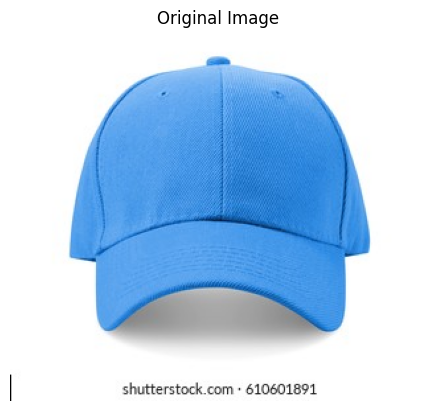

---------------------------------------------------------


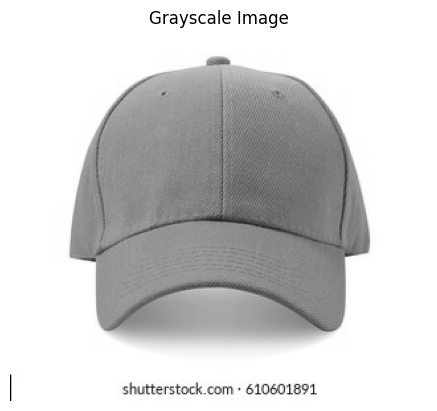

In [9]:
class ReadWriteDisplay:

    def __init__(self, image_path):
        self.image_path = image_path

    def read(self):
        self.image = cv2.imread(self.image_path)
        if self.image is None:
            print("Could Not Read The Image.")
            return

        shape = self.image.shape
        print("Shape Of The Image:", shape)

    def write(self):
        print("Image write operation is not implemented. You can use the show method to display the image instead.")

    def show(self, display_grayscale=False):
        if self.image is None:
            print("Could Not Read The Image.")
            return

        if display_grayscale:
            grayscale_image = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
            image_to_show = grayscale_image
            title = "Grayscale Image"
        else:
            image_to_show = self.image
            title = "Original Image"

        print("-" * 57)
        plt.imshow(cv2.cvtColor(image_to_show, cv2.COLOR_BGR2RGB) if not display_grayscale else image_to_show, cmap='gray' if display_grayscale else None)
        plt.axis('off')
        plt.title(title)
        plt.show()



image_path = "blue_cap.jpg"
reader = ReadWriteDisplay(image_path)
reader.read()
reader.show()

reader.show(display_grayscale=True)

# **Smoothing**

***Smoothing*** : *In image processing refers to techniques that reduce noise and detail in an image, enhancing its quality for analysis or visualization. Common methods include averaging, Gaussian, median, and bilateral blurring, each employing different algorithms to achieve a smoother appearance while preserving essential features. Smoothing is essential for applications like object detection, edge detection, and image segmentation.*

- **Initialization: The class is initialized with the path to an image. It attempts to load the image using OpenCV, raising a ValueError if the image cannot be loaded. It also prints the shape of the loaded image.**

- **Image Display: The display_image method uses Matplotlib to display an image with a given title, enhancing visualization by converting the image from BGR to RGB format.**

- **Averaging Blurs: The class provides methods for average blurring. averaging_numpy implements average blur using a custom NumPy kernel, while average_blurring uses OpenCV’s built-in blur function.**

- **Gaussian Blur: The gaussian_blur method applies Gaussian blur to the image using OpenCV’s GaussianBlur function, which is effective for reducing image noise and detail.**

- **Median and Bilateral Blurs: The class includes methods for median blur (median_blur) and bilateral blur (bilateral_blur), the latter being useful for noise removal while preserving edges, making it ideal for tasks where edge retention is important.**

Image Loaded Successfully With Shape: (280, 316, 3)
---------------------------------------------------------------


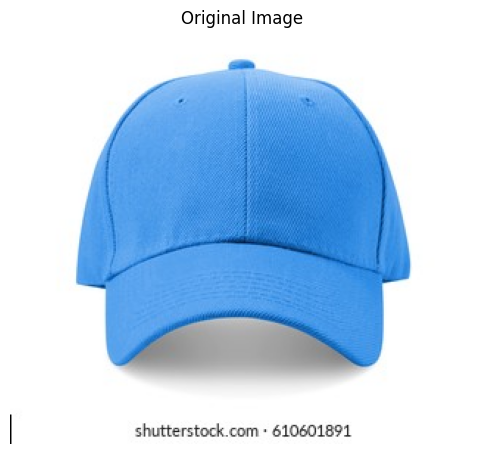

---------------------------------------------------------------


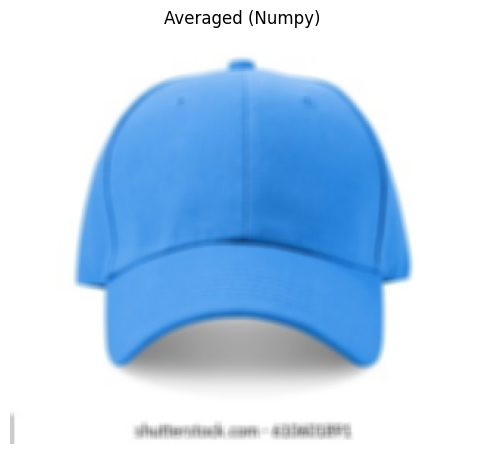

---------------------------------------------------------------


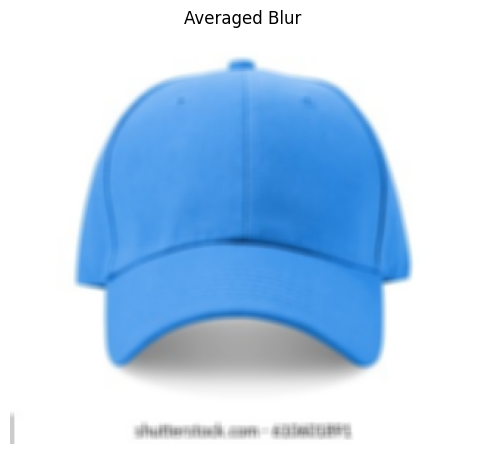

---------------------------------------------------------------


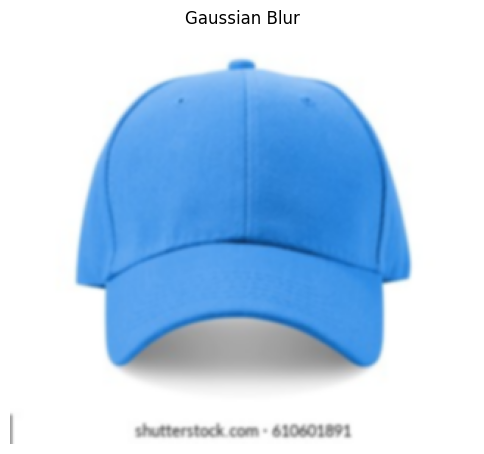

---------------------------------------------------------------


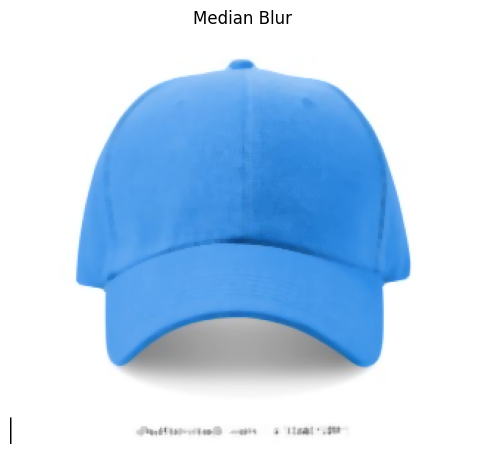

---------------------------------------------------------------


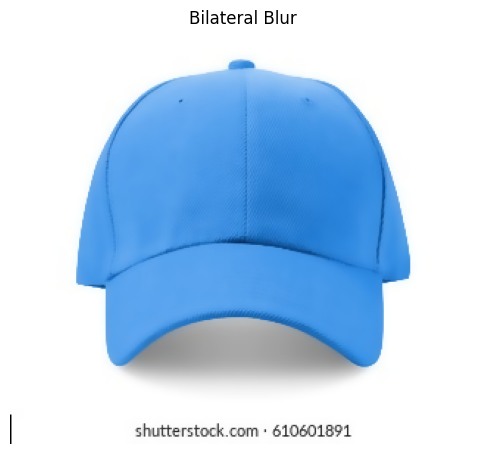

In [12]:
class Smoothing:

    def __init__(self, path):
        self.image_path = path
        self.image = cv2.imread(self.image_path)

        if self.image is None:
            raise ValueError(f"Image At Path '{self.image_path}' Could Not Be Loaded.")
        print("Image Loaded Successfully With Shape:", self.image.shape)


    def display_image(self, image, title):
        print("-" * 63)
        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(title)
        plt.show()


    def averaging_numpy(self):
        kernel = np.ones((5, 5), np.float32) / 25
        dst = cv2.filter2D(self.image, -1, kernel)
        self.display_image(self.image, "Original Image")
        self.display_image(dst, "Averaged (Numpy)")


    def average_blurring(self):
        blur = cv2.blur(self.image, (5, 5))
        self.display_image(blur, "Averaged Blur")


    def gaussian_blur(self):
        blur = cv2.GaussianBlur(self.image, (5, 5), 0)
        self.display_image(blur, "Gaussian Blur")


    def median_blur(self):
        median = cv2.medianBlur(self.image, 5)
        self.display_image(median, "Median Blur")


    def bilateral_blur(self):
        blur = cv2.bilateralFilter(self.image, 9, 75, 75)
        self.display_image(blur, "Bilateral Blur")


image_path = "blue_cap.jpg"
smoothing = Smoothing(image_path)
smoothing.averaging_numpy()
smoothing.average_blurring()
smoothing.gaussian_blur()
smoothing.median_blur()
smoothing.bilateral_blur()

# **Template Matching**

***Template Matching*** : *Is a technique used in computer vision to find and locate a template image within a larger image. By comparing pixel values and calculating correlation coefficients, it identifies regions in the image that match the template, making it useful for object detection and recognition tasks.*

- **Initialization: The class is initialized with paths to an image and a template. It reads both using OpenCV in grayscale mode and raises a ValueError if either cannot be loaded, ensuring valid paths.**

- **Image Display: The display_image method uses Matplotlib to visualize images in grayscale, providing a clear way to review the original and processed images with appropriate titles.**

- **Template Matching: The template_matching method performs standard template matching using OpenCV's matchTemplate function with the TM_CCOEFF method. It draws a rectangle around the matched area in the image and displays the result.**

- **Multiscale Template Matching: The multiscale_template_matching method enhances the template matching process by resizing the image to various scales and applying edge detection. It records the best match found across all scales and draws a bounding box around the detected area.**

- **Usage: The class allows for flexible usage, with the capability to perform both standard and multiscale template matching. The multiscale function can be tested by uncommenting the relevant line in the code, making it easy to evaluate different matching scenarios.**

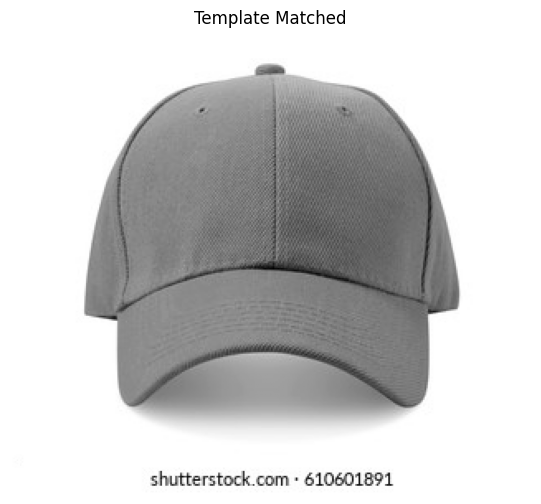

In [13]:
class TemplateMatching:

    def __init__(self, image_path, template_path):
        self.image_path = image_path
        self.template_path = template_path

        self.image = cv2.imread(self.image_path, 0)
        self.template = cv2.imread(self.template_path, 0)

        if self.image is None or self.template is None:
            raise ValueError("Image or template path is incorrect or the file does not exist.")


    def display_image(self, title, img):
        plt.figure(figsize=(10, 6))
        plt.title(title)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.show()


    def template_matching(self):
        img2 = self.image.copy()
        w, h = self.template.shape[::-1]

        img = img2.copy()
        res = cv2.matchTemplate(img, self.template, cv2.TM_CCOEFF)
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
        top_left = max_loc
        bottom_right = (top_left[0] + w, top_left[1] + h)
        cv2.rectangle(img, top_left, bottom_right, 255, 2)

        self.display_image("Template Matched", img)


    def multiscale_template_matching(self):
        template = cv2.Canny(self.template, 50, 200)
        (tH, tW) = self.template.shape[:2]

        gray = self.image
        found = None

        for scale in np.linspace(0.2, 1.0, 20)[::-1]:
            resized = imutils.resize(gray, width=int(gray.shape[1] * scale))
            r = gray.shape[1] / float(resized.shape[1])
            if resized.shape[0] < tH or resized.shape[1] < tW:
                break

            edged = cv2.Canny(resized, 50, 200)
            result = cv2.matchTemplate(edged, template, cv2.TM_CCOEFF)
            (_, maxVal, _, maxLoc) = cv2.minMaxLoc(result)

            if found is None or maxVal > found[0]:
                found = (maxVal, maxLoc, r)

        (_, maxLoc, r) = found
        (startX, startY) = (int(maxLoc[0] * r), int(maxLoc[1] * r))
        (endX, endY) = (int((maxLoc[0] + tW) * r), int((maxLoc[1] + tH) * r))

        cv2.rectangle(self.image, (startX, startY), (endX, endY), (0, 0, 255), 2)

        self.display_image("Multiscale Template Matched", self.image)


image_path = "blue_cap.jpg"
template_path = "blue_cap.jpg"

template_matcher = TemplateMatching(image_path, template_path)
template_matcher.template_matching()
# template_matcher.multiscale_template_matching()  # Uncomment to test multiscale matching